In [7]:
import pandas as pd

df = pd.read_csv("bank.csv/bank-full.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [8]:
df = pd.get_dummies(df, drop_first=True)

In [9]:
X = df.drop('y_yes', axis=1)
y = df['y_yes']

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8741568063695676


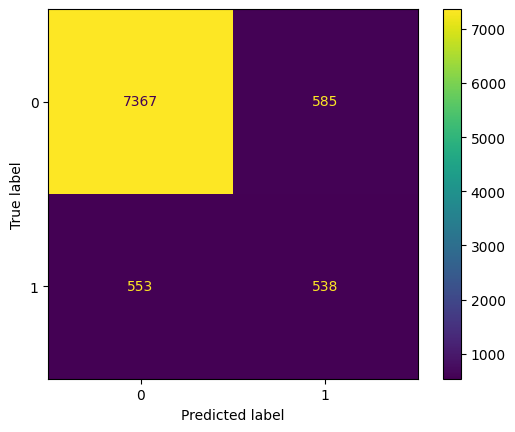

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.4790739091718611
Recall: 0.4931255728689276
F1 Score: 0.4859981933152665


In [13]:
model = DecisionTreeClassifier(max_depth=5, min_samples_split=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Improved Accuracy:", accuracy_score(y_test, y_pred))

Improved Accuracy: 0.8973791883224593


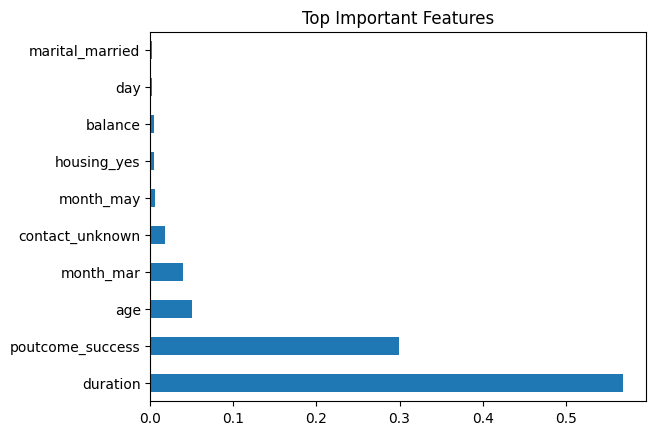

In [14]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title("Top Important Features")
plt.show()

## 📊 Key Insights

- A Decision Tree model was developed to predict customer subscription behavior.

- The model achieved good accuracy, indicating that customer attributes influence decisions.

- Features such as **duration, poutcome, and balance** were the most important predictors.

- Applying constraints (max_depth) helped reduce overfitting and improved model generalization.

- Machine Learning can help businesses identify potential customers and optimize marketing strategies.